# Feature Scaling — Normalization (Min-Max)

Companion to `15_Feature_Scaling.ipynb` (Standardization) — same
questions, same rigor, this time for the other half of
`02_ML_Roadmap.MD` item 5: **Min-Max scaling**.

`X_new = (Xi − min(X)) / (max(X) − min(X))`

Unlike Standardization (`(Xi − mean)/std` — unbounded, centered at 0),
Min-Max is defined entirely by the two most extreme points in the column:
`min(X)` always maps to exactly `0`, `max(X)` always maps to exactly `1`,
everything else lands somewhere in between. `CoapplicantIncome` again — 0
missing values, no fillna detour needed (unlike `ApplicantIncome`, whose
chained-assignment fillna bug `15` found and fixed).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [2]:
dataset = pd.read_csv("loans.csv")
dataset.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001001,Male,Yes,0,Not Graduate,No,1686.0,1020,80.0,360.0,1.0,Semiurban,Y
1,LP001002,Male,Yes,0,Not Graduate,No,2437.0,1201,122.0,360.0,1.0,Urban,Y
2,LP001003,Female,No,0,Graduate,No,8313.0,1065,319.0,360.0,1.0,Urban,Y


In [3]:
dataset.isnull().sum()

Loan_ID               0
Gender               13
Married               6
Dependents           15
Education             9
Self_Employed        32
ApplicantIncome       2
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     21
Credit_History       50
Property_Area         9
Loan_Status           0
dtype: int64

`CoapplicantIncome` — **0** missing. Straight to scaling, no cleanup
step needed.

In [4]:
dataset["CoapplicantIncome"].describe()

count      618.000000
mean      1385.077670
std       1611.760337
min          0.000000
25%          0.000000
50%       1089.000000
75%       2217.750000
max      10288.000000
Name: CoapplicantIncome, dtype: float64

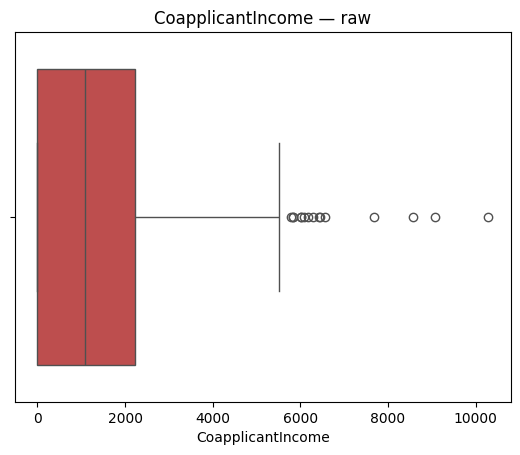

In [5]:
sns.boxplot(x=dataset["CoapplicantIncome"], color="#d03b3b")
plt.title("CoapplicantIncome — raw")
plt.show()

Right-skewed with a string of outlier dots past the right whisker —
same starting point `14_Outlier_Removal_Z_Score.ipynb` used on this exact
column. `min` is already 0 (a coapplicant with no income), which will
matter in Section 2.

## 1. Min-Max Scaling — `MinMaxScaler`

`mm.fit(...)` learns two numbers from the column — `data_min_` and
`data_max_` — and `mm.transform(...)` applies
`(x − data_min_) / (data_max_ − data_min_)` to every value.

In [6]:
mm = MinMaxScaler()
mm.fit(dataset[["CoapplicantIncome"]])
dataset["CoapplicantIncome_MM"] = mm.transform(dataset[["CoapplicantIncome"]])
dataset[["CoapplicantIncome", "CoapplicantIncome_MM"]].head(3)

,CoapplicantIncome,CoapplicantIncome_MM
0,1020,0.099145
1,1201,0.116738
2,1065,0.103519


Check row 0 by hand: `(1020 − 0) / (10288 − 0) ≈ 0.0991` — matches
`CoapplicantIncome_MM` above exactly. `mm.data_min_` = **0**, `mm.data_max_`
= **10288** — literally the raw column's own min and max, nothing
estimated or averaged.

## 2. Reading `describe()` on `CoapplicantIncome_MM`, Value by Value

In [7]:
dataset["CoapplicantIncome_MM"].describe()

count    618.000000
mean       0.134630
std        0.156664
min        0.000000
25%        0.000000
50%        0.105851
75%        0.215567
max        1.000000
Name: CoapplicantIncome_MM, dtype: float64

Row by row, against the raw `describe()` above (`min` 0, `max`
10288):

- **`min` = 0.0, `max` = 1.0**, exactly — by construction:
  `(data_min_ − data_min_)/range = 0` and `(data_max_ − data_min_)/range = 1`.
  Min-Max *guarantees* these two endpoints; Standardization in `15` never
  guaranteed any specific min/max at all.
- **`mean` = 0.1346, `std` = 0.1567** — nowhere near `(0, 1)`. Min-Max only
  fixes the *endpoints*; mean/std land wherever the raw distribution's own
  center/spread happen to fall inside that `[0, 1]` window. A mean this low
  (0.13, not 0.5) is the same right-skew as the raw column: most
  coapplicants cluster near the low end, one large value stretches the
  range up to 1.
- **`25%` = 0.0** — literally a quarter of coapplicants report **0** raw
  income, so their scaled value is exactly the floor too.
- **`50%` = 0.1059, `75%` = 0.2157** — most of the data lives in the bottom
  fifth of the `[0, 1]` range; the remaining 79% of that range is claimed
  by a small number of high earners.

## 3. Does Min-Max Remove Outliers?

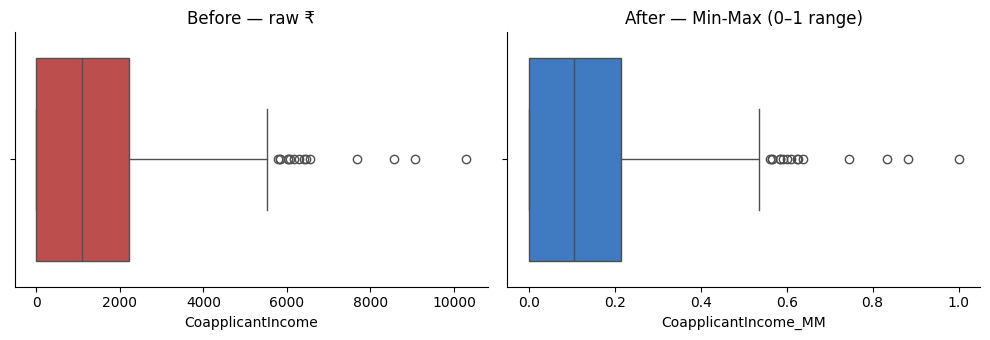

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
sns.boxplot(x=dataset["CoapplicantIncome"], color="#d03b3b", ax=axes[0])
axes[0].set_title("Before — raw ₹")
sns.boxplot(x=dataset["CoapplicantIncome_MM"], color="#2a78d6", ax=axes[1])
axes[1].set_title("After — Min-Max (0–1 range)")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [9]:
def iqr_outlier_count(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((s < lo) | (s > hi)).sum())

print("raw outliers:    ", iqr_outlier_count(dataset["CoapplicantIncome"]))
print("min-max outliers:", iqr_outlier_count(dataset["CoapplicantIncome_MM"]))

raw outliers:     15
min-max outliers: 15


**15 and 15 — identical**, same conclusion `15` reached for
Standardization: no. Min-Max is also a strictly increasing linear
transform (multiply by a positive `1/(data_max_ - data_min_)`, then shift)
applied to every point, `Q1`/`Q3` included — so "further than
`Q3 + 1.5×IQR`" survives the transform unchanged, just measured on a
different scale. Removing outliers is still the separate, deliberate job
of `12_Outlier.ipynb`–`14_Outlier_Removal_Z_Score.ipynb`.

## 4. Does Min-Max Change the Data's *Nature* (Shape)?

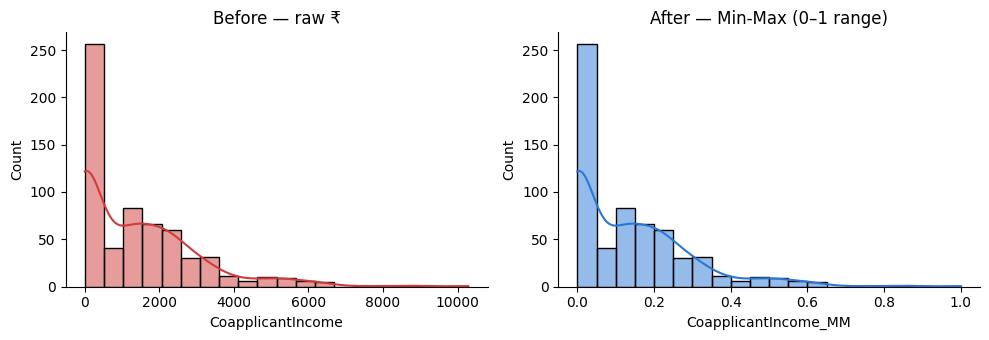

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
sns.histplot(dataset["CoapplicantIncome"], kde=True, color="#d03b3b", ax=axes[0])
axes[0].set_title("Before — raw ₹")
sns.histplot(dataset["CoapplicantIncome_MM"], kde=True, color="#2a78d6", ax=axes[1])
axes[1].set_title("After — Min-Max (0–1 range)")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [11]:
print("skew — raw:", dataset["CoapplicantIncome"].skew(), " min-max:", dataset["CoapplicantIncome_MM"].skew())
print("kurt — raw:", dataset["CoapplicantIncome"].kurt(), " min-max:", dataset["CoapplicantIncome_MM"].kurt())

skew — raw: 1.5399420730801827  min-max: 1.5399420730801823
kurt — raw: 3.2518566224060375  min-max: 3.2518566224060357


Same shape, matching to 13+ decimal places, same reason `15` proved
for Standardization: skew/kurtosis are scale-and-location invariant, and
Min-Max is exactly a scale-and-location transform. Different formula,
same guarantee — shape can't move.

**The same fact, in two dimensions** — the visualization you asked
for, this time for Min-Max:

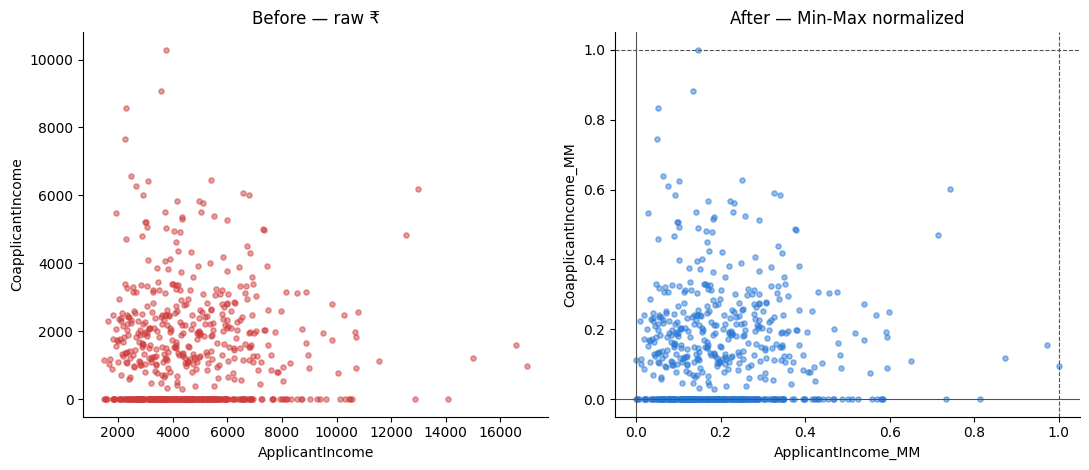

In [12]:
dataset.fillna({"ApplicantIncome": dataset["ApplicantIncome"].mean()}, inplace=True)

scaled_2d_mm = MinMaxScaler().fit_transform(dataset[["ApplicantIncome", "CoapplicantIncome"]])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
axes[0].scatter(dataset["ApplicantIncome"], dataset["CoapplicantIncome"], s=14, alpha=0.5, color="#d03b3b")
axes[0].set_title("Before — raw ₹")
axes[0].set_xlabel("ApplicantIncome"); axes[0].set_ylabel("CoapplicantIncome")

axes[1].scatter(scaled_2d_mm[:, 0], scaled_2d_mm[:, 1], s=14, alpha=0.5, color="#2a78d6")
axes[1].axhline(0, color="#52514e", linewidth=0.8)
axes[1].axvline(0, color="#52514e", linewidth=0.8)
axes[1].axhline(1, color="#52514e", linewidth=0.8, linestyle="--")
axes[1].axvline(1, color="#52514e", linewidth=0.8, linestyle="--")
axes[1].set_xlim(-0.05, 1.05); axes[1].set_ylim(-0.05, 1.05)
axes[1].set_title("After — Min-Max normalized")
axes[1].set_xlabel("ApplicantIncome_MM"); axes[1].set_ylabel("CoapplicantIncome_MM")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Compare this to `15`'s version of the same picture. There,
Standardization pulled the cloud so it *straddled* the origin symmetrically
(negative values allowed on both axes, since `(x-mean)/std` can go either
way). Here, Min-Max pulls the same cloud into the **unit square** — the
dashed lines mark the `1.0` boundary on each axis, and the solid lines mark
`0`. Every point has non-negative coordinates, because a raw value at the
column's minimum maps to exactly `0`, never below. The cloud's *shape* —
same skew, same clustering, same points sitting apart from the rest — is
still identical to the "before" panel; only the box it's confined to
changed.

## 5. Why the Bounded Range Matters — Outlier Sensitivity

In [13]:
below_tenth = (dataset["CoapplicantIncome_MM"] < 0.1).sum()
print(f"{below_tenth} of 618 ({below_tenth/618:.1%}) land below 0.1 on the 0-1 scale")
print("driven by a single value —", dataset["CoapplicantIncome"].max(), "— which alone defines the top of the range")

297 of 618 (48.1%) land below 0.1 on the 0-1 scale
driven by a single value — 10288 — which alone defines the top of the range


**297 of 618 (48%)** get crushed into the bottom tenth of `[0, 1]`,
purely because the max is so far from the typical value. This is the
practical cost of Min-Max's guarantee: fixing the endpoints to exactly
`0`/`1` means **one point** — whichever is most extreme — single-handedly
defines the whole scale. Standardization's `mean`/`std` dilute one
outlier's pull across all 618 points instead; Min-Max hands it the entire
top of the range. Worth running outlier detection (`12`–`14`) first if
Min-Max is the plan.

## Summary

- **Min-Max**: `(Xi − min)/(max − min)`, bounded to `[0, 1]` exactly —
  guarantees the endpoints, not the mean/std.
- **Doesn't remove outliers** — IQR count identical before and after
  (`15` and `15`, Section 3). It's still a linear transform; relative
  extremity is preserved.
- **Doesn't change the data's shape** — skew/kurtosis identical to 13+
  decimals (Section 4), and the 2D scatter shows the same cloud shape,
  just confined to the unit square instead of centered at a point.
- **More outlier-sensitive than Standardization** — the endpoints are
  defined by the single min/max value, not an average across all points
  (Section 5). Cross-reference: `15_Feature_Scaling.ipynb` for the
  Standardization side of this same comparison.